In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
# from saqc import SaQC
import metpyqc as qc
import sys

function_path = './func/'
sys.path.append(function_path)

sys.path.append(function_path)

# from qc_func import *
# from fake_data_design import *

In [3]:
from visualizaion_func import *

In [4]:
from crmprtd import setup_logging
import sqlalchemy as sa
from sqlalchemy.orm import Session
import sys
function_path = '../'
sys.path.append(function_path)

save_path = './comparison_forms/'
db_url = "postgresql://tongli1997@db.pcic.uvic.ca:5433/crmp?keepalives=1&keepalives_idle=300&keepalives_interval=300&keepalives_count=9&passfile=/workspaces/crmprtd/.pgpass"
log_file_path = save_path

engine = sa.create_engine(db_url, echo=False)
session = Session(engine)

session

#### Find the stations under network 2, and have all the variables I want

In [5]:
sql_text = sa.text("""
SELECT s.station_id, h.station_name
FROM meta_history h
JOIN meta_station s
    ON h.station_id = s.station_id
WHERE s.network_id = 2

AND EXISTS (
    SELECT 1 FROM obs_raw o JOIN meta_vars v ON o.vars_id = v.vars_id
    WHERE o.history_id = h.history_id AND v.standard_name = 'lwe_thickness_of_precipitation_amount'
)
;

""")

with engine.begin() as conn:
    df = pd.read_sql(sql_text, conn)

df

,station_id,station_name
0,2654,Brandywine
1,2655,Tantalus
2,2657,Mt. Strachan Precip
3,2658,Mt. Strachan
4,2659,Mt. Harvey Raws
...,...,...
193,14854,Highline
194,14858,Galena Road
195,14859,Slocan Lake
196,15108,NaN


In [6]:
first_station_id = int(df.iloc[1]["station_id"])

sql_vars = sa.text("""
SELECT DISTINCT v.vars_id, v.standard_name, v.net_var_name
FROM meta_history h
JOIN obs_raw o 
    ON h.history_id = o.history_id
JOIN meta_vars v 
    ON o.vars_id = v.vars_id
WHERE h.station_id = :station_id
ORDER BY v.standard_name
""")

with engine.begin() as conn:
    vars_df = pd.read_sql(sql_vars, conn, params={
                          "station_id": first_station_id})


vars_df

,vars_id,standard_name,net_var_name
0,725,air_pressure,stn_pres
1,439,air_pressure,ATMOSPHERIC_PRESSURE
2,733,air_pressure_at_mean_sea_level,mslp
3,721,air_temperature,air_temp
4,720,air_temperature,max_air_temp_snc_last_reset
5,435,air_temperature,MINIMUM_AIR_TEMPERATURE
6,434,air_temperature,CURRENT_AIR_TEMPERATURE1
7,722,air_temperature,min_air_temp_snc_last_reset
8,433,air_temperature,MAXIMUM_AIR_TEMPERATURE
9,436,air_temperature,CURRENT_AIR_TEMPERATURE2


In [7]:
first_station_id = int(df.iloc[1]["station_id"])

sql_obs = sa.text("""
SELECT 
    o.obs_time,
    o.vars_id,
    v.net_var_name,
    o.datum
FROM meta_history h
JOIN obs_raw o 
    ON h.history_id = o.history_id
JOIN meta_vars v 
    ON o.vars_id = v.vars_id
WHERE h.station_id = :station_id
  AND v.standard_name = :std_name
ORDER BY o.vars_id
""")

with engine.begin() as conn:
    obs_df = pd.read_sql(
        sql_obs,
        conn,
        params={
            "station_id": first_station_id,
            "std_name": "lwe_thickness_of_precipitation_amount"
        }
    )

obs_df

,obs_time,vars_id,net_var_name,datum
0,2009-06-25 16:00:00,440,PRECIPITATION_GAUGE_TOTAL,176.1
1,2009-06-25 17:00:00,440,PRECIPITATION_GAUGE_TOTAL,176.4
2,2009-06-25 18:00:00,440,PRECIPITATION_GAUGE_TOTAL,176.7
3,2009-06-25 19:00:00,440,PRECIPITATION_GAUGE_TOTAL,176.9
4,2009-06-25 20:00:00,440,PRECIPITATION_GAUGE_TOTAL,177.1
...,...,...,...,...
175647,2026-03-20 05:00:00,732,pcpn_amt_pst24hrs,48.5
175648,2026-03-20 06:00:00,732,pcpn_amt_pst24hrs,48.2
175649,2026-03-20 07:00:00,732,pcpn_amt_pst24hrs,48.1
175650,2026-03-20 08:00:00,732,pcpn_amt_pst24hrs,45.2


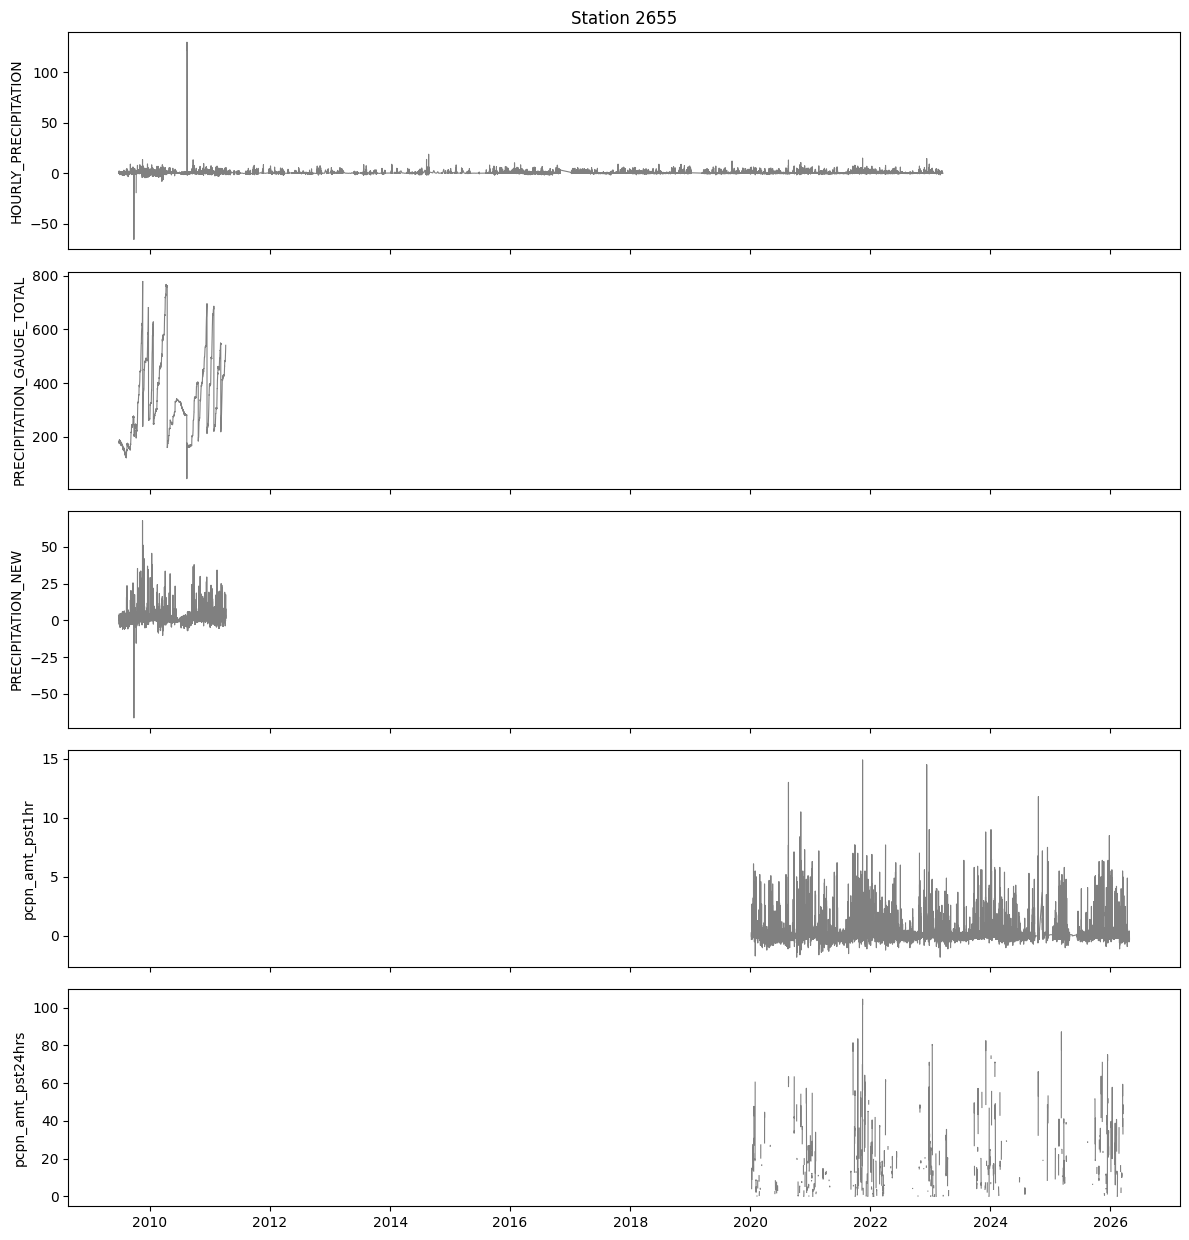

In [9]:
from visualizaion_func import *

df_sql_list = []


obs_df["obs_time"] = pd.to_datetime(obs_df["obs_time"])

df_sql = obs_df.pivot_table(
    index="obs_time",
    columns="net_var_name",
    values="datum"
).sort_index()


plot_weather_data(df_sql, title=f"Station {first_station_id}")

In [13]:
df_sql

net_var_name,HOURLY_PRECIPITATION,PRECIPITATION_GAUGE_TOTAL,PRECIPITATION_NEW,pcpn_amt_pst1hr,pcpn_amt_pst24hrs
obs_time,,,,,
2009-06-25 16:00:00,NaN,176.1,0.0,NaN,NaN
2009-06-25 17:00:00,0.3,176.4,0.3,NaN,NaN
2009-06-25 18:00:00,0.3,176.7,0.6,NaN,NaN
2009-06-25 19:00:00,0.2,176.9,0.2,NaN,NaN
2009-06-25 20:00:00,0.2,177.1,0.4,NaN,NaN
...,...,...,...,...,...
2026-04-27 12:00:00,NaN,NaN,NaN,0.0,NaN
2026-04-27 13:00:00,NaN,NaN,NaN,-0.2,NaN
2026-04-27 14:00:00,NaN,NaN,NaN,0.0,NaN


In [15]:
from func_2_naught_check import *

qc_result = qc_trace_values(df_sql, value_col='HOURLY_PRECIPITATION')

qc_result.sum()

flag_HOURLY_PRECIPITATION_trace    0
dtype: int64